# XGBoost

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.models.xgboost import *

C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## I. Full data

In [2]:
inf_data = pd.read_csv('..//data//processed//combined_macro_data.csv').set_index(['Date'])
inf_data.index = pd.to_datetime(inf_data.index)
inf_rate = inf_data['InflationRate'].dropna()

In [3]:
n_splits = 5
months_ahead = 6
test_size = months_ahead

inf_train = inf_rate[:-test_size]
inf_test = inf_rate[-test_size:]

In [4]:
target_col = 'InflationRate'
final_train_inf, forecast_feat = train_forecast_split(inf_train, target_col) 
final_train_inf.tail()

,InflationRate,Month_Sin,Month_Cos,InflationRate_Lag1,InflationRate_Lag2,InflationRate_Lag13,InflationRate_Lag24,InflationRate_RollMean3,InflationRate_RollSTD3,InflationRate_RollMean6,InflationRate_RollSTD6,InflationRate_RollMean12,InflationRate_RollSTD12
Date,,,,,,,,,,,,,
2025-07-01,0.948617,-0.500000,-8.660254e-01,1.353503,1.273885,3.715937,4.663212,1.353884,0.080189,1.794929,0.610299,2.341078,0.919523
2025-08-01,1.500790,-0.866025,-5.000000e-01,0.948617,1.353503,4.372937,5.331040,1.192002,0.214504,1.472262,0.391528,2.055718,0.746756
2025-09-01,1.741884,-1.000000,-1.836970e-16,1.500790,0.948617,3.346939,6.078767,1.267637,0.285926,1.377108,0.265940,1.901872,0.638945
2025-10-01,1.660079,-0.866025,5.000000e-01,1.741884,1.500790,1.937046,4.919423,1.397097,0.406673,1.375490,0.263221,1.885609,0.640450
2025-11-01,1.496063,-0.500000,8.660254e-01,1.660079,1.741884,2.263541,4.117647,1.634251,0.122605,1.413126,0.288258,1.835321,0.631710


In [5]:
test_results = test_diag(final_train_inf, 'InflationRate', n_iter = 100)

Rows      : 815
CV RMSE   : 0.540
Test RMSE : 0.594
Test STD  : 1.016
R²        : 0.658
Best Params:
{'colsample_bytree': 0.9823598442410485, 'gamma': 3.970985823468025, 'learning_rate': 0.009663111819311426, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 2176, 'reg_alpha': 0.002654338379455361, 'reg_lambda': 91.56208974433525, 'subsample': 0.693012319380772}


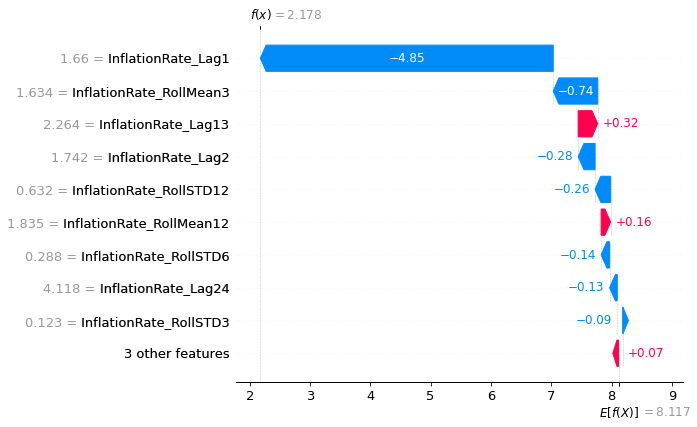

In [6]:
nexog_train_forecast = months_ahead_forecast(inf_train, target_col, months_ahead = months_ahead)

In [7]:
eval_metrics(inf_test, nexog_train_forecast)

{'RMSE': 2.822347485668109,
 'MAE': 2.0304280155825816,
 'MSE': 7.965645329857097,
 'MAPE': nan,
 'STD': 2.2082739170581256}

In [8]:
final_inf, forecast_feat = train_forecast_split(inf_rate, target_col) 
final_inf.tail()

,InflationRate,Month_Sin,Month_Cos,InflationRate_Lag1,InflationRate_Lag2,InflationRate_Lag13,InflationRate_Lag24,InflationRate_RollMean3,InflationRate_RollSTD3,InflationRate_RollMean6,InflationRate_RollSTD6,InflationRate_RollMean12,InflationRate_RollSTD12
Date,,,,,,,,,,,,,
2026-01-01,2.024922,0.500000,8.660254e-01,1.801096,1.496063,2.900886,2.800659,1.652413,0.152661,1.524755,0.308271,1.659842,0.482085
2026-02-01,2.419984,0.866025,5.000000e-01,2.024922,1.801096,2.884615,3.377265,1.774027,0.265467,1.704139,0.200157,1.588201,0.320240
2026-03-01,4.068858,1.000000,6.123234e-17,2.419984,2.024922,2.071713,3.715937,2.082001,0.313367,1.857338,0.325754,1.617223,0.378521
2026-04-01,7.227023,0.866025,-5.000000e-01,4.068858,2.419984,1.751592,3.804797,2.837921,1.084169,2.245167,0.949273,1.810329,0.804591
2026-05-01,6.761006,0.500000,-8.660254e-01,7.227023,4.068858,1.434263,3.887510,4.571955,2.442690,3.172991,2.182522,2.293059,1.745744


In [9]:
test_results = test_diag(final_inf, 'InflationRate', n_iter = 100)

Rows      : 821
CV RMSE   : 0.541
Test RMSE : 0.942
Test STD  : 1.581
R²        : 0.645
Best Params:
{'colsample_bytree': 0.9823598442410485, 'gamma': 3.970985823468025, 'learning_rate': 0.009663111819311426, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 2176, 'reg_alpha': 0.002654338379455361, 'reg_lambda': 91.56208974433525, 'subsample': 0.693012319380772}


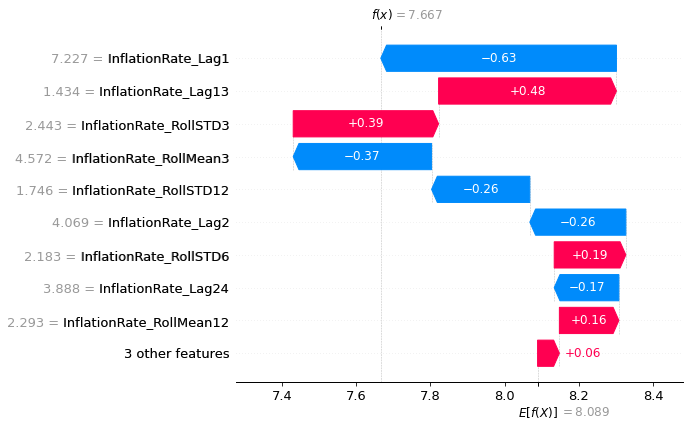

In [10]:
nexog_forecast = months_ahead_forecast(inf_rate, target_col, months_ahead = months_ahead)

In [11]:
nexog_forecast.columns = ['XGBoost NExog Full Forecast']
nexog_forecast.to_csv('..//outputs//forecasts//xgboost_full_nexog_forecast.csv')

nexog_forecast

,XGBoost NExog Full Forecast
Date,
2026-06-01,7.666690
2026-07-01,7.125916
2026-08-01,8.591007
2026-09-01,8.021852
2026-10-01,8.867754
2026-11-01,8.774572


## II. Reduced data

In [12]:
inf_full = inf_data.dropna()
inf_full_train = inf_full[:-test_size]
inf_full_test = inf_full[-test_size:]

In [13]:
inf_red_train, red_train_forecast_feat = train_forecast_split(inf_full_train[target_col], target_col) 
inf_red_train.tail()

,InflationRate,Month_Sin,Month_Cos,InflationRate_Lag1,InflationRate_Lag2,InflationRate_Lag13,InflationRate_Lag24,InflationRate_RollMean3,InflationRate_RollSTD3,InflationRate_RollMean6,InflationRate_RollSTD6,InflationRate_RollMean12,InflationRate_RollSTD12
Date,,,,,,,,,,,,,
2025-07-01,0.948617,-0.500000,-8.660254e-01,1.353503,1.273885,3.715937,4.663212,1.353884,0.080189,1.794929,0.610299,2.341078,0.919523
2025-08-01,1.500790,-0.866025,-5.000000e-01,0.948617,1.353503,4.372937,5.331040,1.192002,0.214504,1.472262,0.391528,2.055718,0.746756
2025-09-01,1.741884,-1.000000,-1.836970e-16,1.500790,0.948617,3.346939,6.078767,1.267637,0.285926,1.377108,0.265940,1.901872,0.638945
2025-10-01,1.660079,-0.866025,5.000000e-01,1.741884,1.500790,1.937046,4.919423,1.397097,0.406673,1.375490,0.263221,1.885609,0.640450
2025-11-01,1.496063,-0.500000,8.660254e-01,1.660079,1.741884,2.263541,4.117647,1.634251,0.122605,1.413126,0.288258,1.835321,0.631710


In [14]:
test_red_results = test_diag(inf_red_train, 'InflationRate', n_iter = 100)

Rows      : 251
CV RMSE   : 0.789
Test RMSE : 0.528
Test STD  : 1.016
R²        : 0.730
Best Params:
{'colsample_bytree': 0.7612995364546475, 'gamma': 2.8105502070862536, 'learning_rate': 0.04048828894913303, 'max_depth': 2, 'min_child_weight': 2, 'n_estimators': 739, 'reg_alpha': 0.026254585137741815, 'reg_lambda': 0.22911643362135878, 'subsample': 0.9933954833738137}


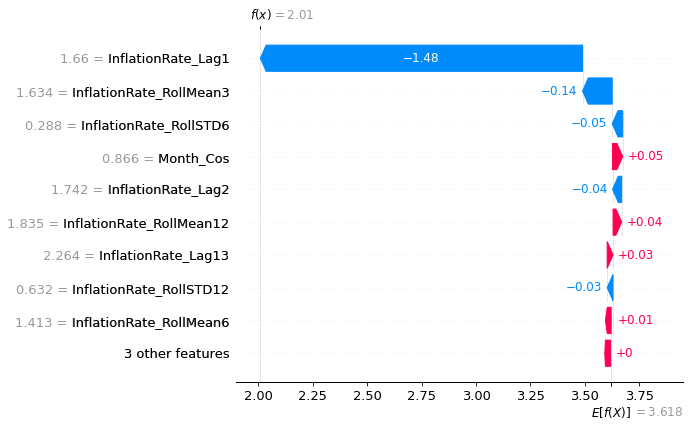

In [15]:
nexog_red_train_forecast = months_ahead_forecast(inf_full_train[target_col], target_col = target_col, months_ahead = months_ahead)

In [16]:
eval_metrics(inf_full_test[target_col], nexog_red_train_forecast)

{'RMSE': 3.0494589587071435,
 'MAE': 2.206337316227774,
 'MSE': 9.299199940839257,
 'MAPE': nan,
 'STD': 2.2082739170581256}

In [17]:
inf_red, red_forecast_feat = train_forecast_split(inf_full[target_col], target_col) 
inf_red.tail()

,InflationRate,Month_Sin,Month_Cos,InflationRate_Lag1,InflationRate_Lag2,InflationRate_Lag13,InflationRate_Lag24,InflationRate_RollMean3,InflationRate_RollSTD3,InflationRate_RollMean6,InflationRate_RollSTD6,InflationRate_RollMean12,InflationRate_RollSTD12
Date,,,,,,,,,,,,,
2026-01-01,2.024922,0.500000,8.660254e-01,1.801096,1.496063,2.900886,2.800659,1.652413,0.152661,1.524755,0.308271,1.659842,0.482085
2026-02-01,2.419984,0.866025,5.000000e-01,2.024922,1.801096,2.884615,3.377265,1.774027,0.265467,1.704139,0.200157,1.588201,0.320240
2026-03-01,4.068858,1.000000,6.123234e-17,2.419984,2.024922,2.071713,3.715937,2.082001,0.313367,1.857338,0.325754,1.617223,0.378521
2026-04-01,7.227023,0.866025,-5.000000e-01,4.068858,2.419984,1.751592,3.804797,2.837921,1.084169,2.245167,0.949273,1.810329,0.804591
2026-05-01,6.761006,0.500000,-8.660254e-01,7.227023,4.068858,1.434263,3.887510,4.571955,2.442690,3.172991,2.182522,2.293059,1.745744


In [18]:
test_red_results = test_diag(inf_red, 'InflationRate', n_iter = 100)

Rows      : 257
CV RMSE   : 0.837
Test RMSE : 0.912
Test STD  : 1.581
R²        : 0.667
Best Params:
{'colsample_bytree': 0.9604082439414403, 'gamma': 0.9009989024436044, 'learning_rate': 0.02228131332262713, 'max_depth': 8, 'min_child_weight': 9, 'n_estimators': 1181, 'reg_alpha': 0.15428032656618226, 'reg_lambda': 1.1058953027263159, 'subsample': 0.7742083053299873}


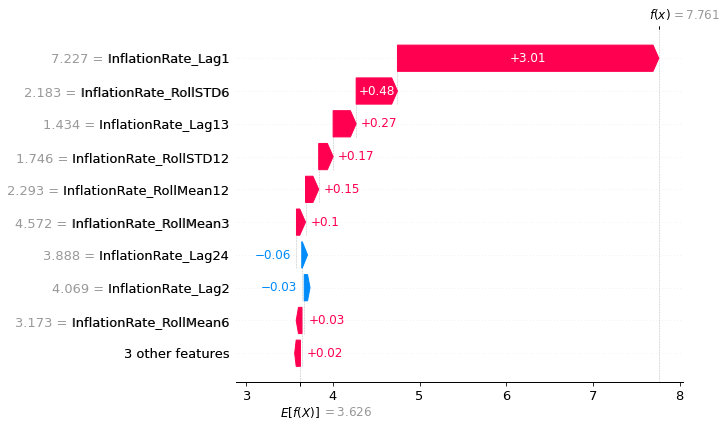

In [19]:
nexog_red_forecast = months_ahead_forecast(inf_full[target_col], target_col, months_ahead = months_ahead)

In [20]:
nexog_red_forecast.columns = ['XGBoost NExog Red Forecast']
nexog_red_forecast.to_csv('..//outputs//forecasts//xgboost_red_nexog_forecast.csv')

nexog_red_forecast

,XGBoost NExog Red Forecast
Date,
2026-06-01,7.760535
2026-07-01,7.631982
2026-08-01,8.992358
2026-09-01,8.615250
2026-10-01,8.730096
2026-11-01,8.269925


## III. Reduced data with exogenous variables

In [21]:
inf_exog_full_train, forecast_train_feat = train_forecast_split(inf_full_train, target_col) 
inf_exog_full_train.tail()

,InflationRate,USD_PHP,UnemploymentRate,DubaiCrude,Month_Sin,Month_Cos,InflationRate_Lag1,InflationRate_Lag2,InflationRate_Lag13,InflationRate_Lag24,...,DubaiCrude_Lag1,DubaiCrude_Lag2,DubaiCrude_Lag13,DubaiCrude_Lag24,DubaiCrude_RollMean3,DubaiCrude_RollSTD3,DubaiCrude_RollMean6,DubaiCrude_RollSTD6,DubaiCrude_RollMean12,DubaiCrude_RollSTD12
Date,,,,,,,,,,,,,,,,,,,,,
2025-07-01,0.948617,56.752348,5.3,71.043043,-0.500000,-8.660254e-01,1.353503,1.273885,3.715937,4.663212,...,69.362857,63.607273,84.112500,80.645714,67.153225,3.101774,71.927270,6.112815,74.564967,5.844009
2025-08-01,1.500790,57.252526,3.9,69.388095,-0.866025,-5.000000e-01,0.948617,1.353503,4.372937,5.331040,...,71.043043,69.362857,85.201304,86.123043,68.004391,3.899583,70.300386,4.311180,73.385111,4.845283
2025-09-01,1.741884,57.250091,3.8,69.919091,-1.000000,-1.836970e-16,1.500790,0.948617,3.346939,6.078767,...,69.388095,71.043043,80.089091,93.238571,69.931332,0.962853,69.144818,3.146356,72.493362,4.469438
2025-10-01,1.660079,58.298409,5.0,64.598696,-0.866025,5.000000e-01,1.741884,1.500790,1.937046,4.919423,...,69.919091,69.388095,73.760000,88.787727,70.116743,0.844993,68.634984,2.601680,72.173286,4.507850
2025-11-01,1.496063,58.913550,4.4,64.355500,-0.500000,8.660254e-01,1.660079,1.741884,2.263541,4.117647,...,64.598696,69.919091,76.070000,82.640909,67.968627,2.930498,67.986509,3.085159,71.217344,4.812407


In [22]:
test_exog_results = test_diag(inf_exog_full_train, 'InflationRate', n_iter = 100)

Rows      : 251
CV RMSE   : 0.737
Test RMSE : 0.569
Test STD  : 1.016
R²        : 0.687
Best Params:
{'colsample_bytree': 0.8405808457315322, 'gamma': 3.876602782234151, 'learning_rate': 0.1613649031098962, 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 306, 'reg_alpha': 3.4928143364083234e-05, 'reg_lambda': 3.0980422262731806, 'subsample': 0.74731873714231}


c:\Users\PC\Desktop\Acads Stuff\Inflation Forecasting\src\models\xgboost.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[forecast_feat_exog.index[0], col] = exog_forecast


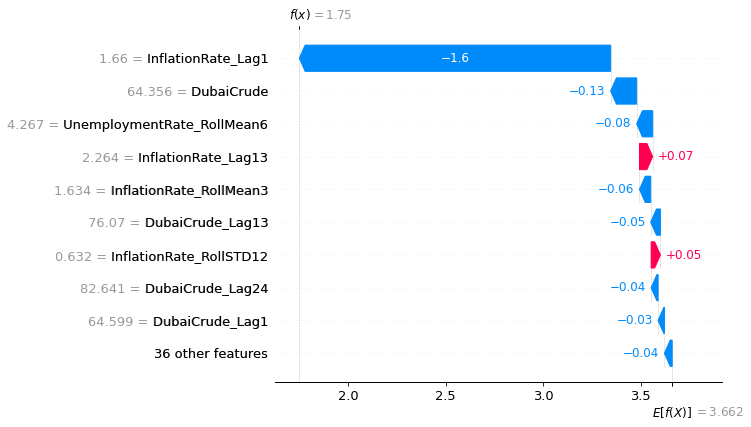

In [23]:
exog_train_forecast = months_ahead_forecast(inf_full_train, target_col, months_ahead = months_ahead)

In [24]:
eval_metrics(inf_full_test[target_col], exog_train_forecast[target_col])

{'RMSE': 3.422768248873263,
 'MAE': 2.535950604253568,
 'MSE': 11.715342485494944,
 'MAPE': 47.95308597482399,
 'STD': 2.2082739170581256}

In [25]:
inf_exog_full, forecast_feat = train_forecast_split(inf_full, target_col) 
inf_exog_full.tail()

,InflationRate,USD_PHP,UnemploymentRate,DubaiCrude,Month_Sin,Month_Cos,InflationRate_Lag1,InflationRate_Lag2,InflationRate_Lag13,InflationRate_Lag24,...,DubaiCrude_Lag1,DubaiCrude_Lag2,DubaiCrude_Lag13,DubaiCrude_Lag24,DubaiCrude_RollMean3,DubaiCrude_RollSTD3,DubaiCrude_RollMean6,DubaiCrude_RollSTD6,DubaiCrude_RollMean12,DubaiCrude_RollSTD12
Date,,,,,,,,,,,,,,,,,,,,,
2026-01-01,2.024922,59.162190,5.8,62.728182,0.500000,8.660254e-01,1.801096,1.496063,2.900886,2.800659,...,61.830000,64.355500,74.002727,79.582174,63.594732,1.533132,66.855738,3.739892,69.391504,5.509725
2026-02-01,2.419984,58.280263,5.1,68.508500,0.866025,5.000000e-01,2.024922,1.801096,2.884615,3.377265,...,62.728182,61.830000,80.804348,82.809048,62.971227,1.280172,65.469927,3.403361,67.885156,4.480723
2026-03-01,4.068858,59.406905,5.0,126.706364,1.000000,6.123234e-17,2.419984,2.024922,2.071713,3.715937,...,68.508500,62.728182,76.321500,86.633810,64.355561,3.624481,65.323328,3.214538,67.234073,3.630370
2026-04-01,7.227023,60.291316,4.7,105.299091,0.866025,-5.000000e-01,4.068858,2.419984,1.751592,3.804797,...,126.706364,68.508500,72.978095,90.869545,85.981015,35.387406,74.787874,25.538037,71.711429,17.602620
2026-05-01,6.761006,61.441000,4.8,102.282308,0.500000,-8.660254e-01,7.227023,4.068858,1.434263,3.887510,...,105.299091,126.706364,68.489545,84.666087,100.171318,29.435835,81.571273,27.611536,74.778891,20.030007


In [26]:
test_exog_results = test_diag(inf_full, 'InflationRate', n_iter = 100)

Rows      : 257
CV RMSE   : 1.924
Test RMSE : 2.915
Test STD  : 1.581
R²        : -2.401
Best Params:
{'colsample_bytree': 0.5260203103049141, 'gamma': 3.2434365963372107, 'learning_rate': 0.04768857216302327, 'max_depth': 2, 'min_child_weight': 4, 'n_estimators': 346, 'reg_alpha': 8.528731285664739, 'reg_lambda': 0.13503306019388092, 'subsample': 0.5954323221327099}


c:\Users\PC\Desktop\Acads Stuff\Inflation Forecasting\src\models\xgboost.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[forecast_feat_exog.index[0], col] = exog_forecast


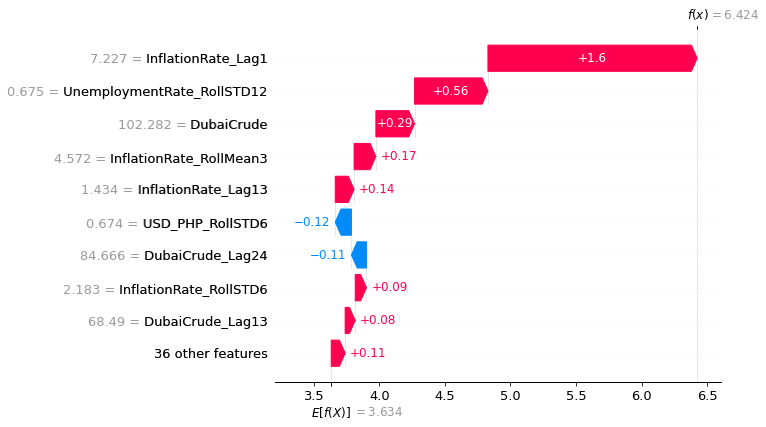

In [27]:
exog_forecast = months_ahead_forecast(inf_full, target_col, months_ahead = months_ahead)

In [28]:
nexog_red_forecast.columns = ['XGBoost NExog Red Forecast']
exog_forecast.to_csv('..//outputs//forecasts//xgboost_exog_forecast.csv')

exog_forecast

,InflationRate,USD_PHP,UnemploymentRate,DubaiCrude
Date,,,,
2026-06-01,6.424090,59.548710,5.140977,94.246414
2026-07-01,6.894938,58.674183,5.076282,90.799149
2026-08-01,6.155706,58.777184,4.713942,85.652977
2026-09-01,6.280259,58.526009,4.735344,84.045143
2026-10-01,5.945511,58.589569,4.937060,80.858452
2026-11-01,5.776960,57.322430,4.694580,80.402954


## IV. All forecasts

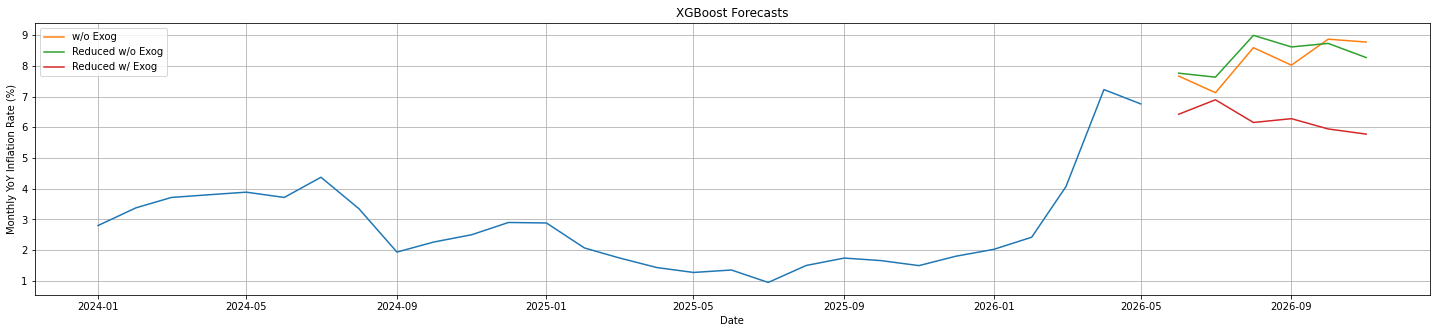

In [29]:
plt.figure(figsize = (25, 5))
plt.plot(inf_rate['2024':])
plt.title('XGBoost Forecasts')
plt.plot(nexog_forecast['XGBoost NExog Full Forecast'], label = 'w/o Exog')
plt.plot(nexog_red_forecast['XGBoost NExog Red Forecast'], label = 'Reduced w/o Exog')
plt.plot(exog_forecast[target_col], label = 'Reduced w/ Exog')
plt.xlabel('Date')
plt.ylabel('Monthly YoY Inflation Rate (%)')
plt.legend()
plt.grid(True)
plt.savefig('..//outputs//figures//xgboost_forecast.jpg', dpi = 300, bbox_inches = 'tight')
plt.savefig('..//outputs//figures//xgboost_forecast.png', dpi = 300, bbox_inches = 'tight')
plt.show()